# Meaningful Representation of Sequential Data

**Authors:** Natalia Sperczyńska, 278444 and Weronika Łaszkiewicz, 278434

**Course:** Artificial Intelligence 1, W11MIP-SI0044W

**Date:** 25 May 2026

**Repository:** [github.com/wlaszkiewicz/transformers-vs-word2vec](https://github.com/wlaszkiewicz/transformers-vs-word2vec)

**Chosen task:** Illustrate with diverse examples how Transformer encoder-generated embeddings capture context, in contrast to word2vec embeddings.

## Setup

In [2]:
%pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import gensim.downloader as api
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

import torch

import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import widgets
from IPython.display import display

%matplotlib inline

### Words and Groups

All words, example sentences, semantic groups, and colors are defined here once and reused throughout the notebook. Words were chosen inspired by the lecture, sentences were generated using a prompt to Gemini.

Word2Vec uses one vector per word type so `mole` appears once. BERT produces contextual embeddings, so `mole` appears three times with different sentences, one per sense.

In [4]:
# shared base used by both W2V and BERT
word_sentences = {
    'king':      'The king sat upon his throne and addressed the court.',
    'queen':     'The queen wore a golden crown at the royal ceremony.',
    'man':       'The man walked quickly through the crowded street.',
    'dog':       'The dog wagged its tail and ran across the garden.',
    'animal':    'The animal was spotted near the edge of the forest.',
    'freckle':   'She had a small freckle just above her cheekbone.',
    'atom': 'A single atom of hydrogen is the smallest unit of that element.',
    'bank':      'She deposited her savings at the bank before closing time.',
    'river':     'They canoed down the river as the sun set behind the hills.',
    'mole':      'The mole burrowed quickly through the soft garden soil.',
}

# BERT-only: same word, different sentences per sense
mole_senses = {
    'mole (animal)':    'The mole burrowed quickly through the soft garden soil.',
    'mole (chemistry)': 'A mole represents exactly 6.022 times ten to the twenty-third power of particles.',
    'mole (skin)':      'The dermatologist examined the mole on her shoulder for signs of change.',
}

word_groups = {
    'king':             'royalty',
    'queen':            'royalty',
    'man':              'people',
    'dog':              'animals',
    'animal':           'animals',
    'freckle':          'skin',
    'atom':             'science',
    'bank':             'finance',
    'river':            'geography',
    'mole':             'ambiguous',
    'mole (animal)':    'ambiguous',
    'mole (chemistry)': 'ambiguous',
    'mole (skin)':      'ambiguous',
}

group_colors = {
    'royalty':   '#f7a07e',
    'people':    '#7eb8f7',
    'animals':   '#a0f7b8',
    'skin':      '#d4a0f7',
    'science':   '#f7c0e0',
    'finance':   '#f7e07e',
    'geography': '#80d8f0',
    'ambiguous': '#f76e6e',
}

# W2V uses the base word list
words = list(word_sentences.keys())

# BERT replaces 'mole' with the 3 senses
bert_words = [w for w in words if w != 'mole'] + list(mole_senses.keys())
bert_sentences = {**{k: (v, k) for k, v in word_sentences.items() if k != 'mole'},
                  **{k: (v, 'mole') for k, v in mole_senses.items()}}

pairs = [
    ('king',   'queen'),
    ('king',   'man'),
    ('dog',    'animal'),
    ('bank',   'river'),
    ('mole',   'freckle'),
    ('mole',   'atom'),
    ('mole',   'animal'),
]

## Word2Vec

Word2vec is a technique in natural language processing for obtaining words as high-dimensional vectors of numbers which capture relationships between words. In particular, words which appear in similar contexts are mapped to vectors which are nearby as measured by cosine similarity [https://en.wikipedia.org/wiki/Word2vec].


**Architectures:**

- **Continuous Bag of Words (CBOW):** Predicts the target word given its surrounding context words.
- **Skip-Gram:** Predicts the context words given a target word.

### Loading the Pretrained Model

We decided to use a pretrained model avaiable in the the Genism database [https://github.com/piskvorky/gensim-data]. We chose the `word2vec-google-news-300` model, which is a 300-dimensional vectors trained on ~100 billion words of Google News text. This gives clean, well-learned geometry without hours of training.

In [5]:
print('Downloading word2vec-google-news-300 (~1.6 GB) ...')
w2v = api.load('word2vec-google-news-300')
print(f'Loaded: {len(w2v)} words, {w2v.vector_size}-dimensional vectors')

Loaded: 3000000 words, 300-dimensional vectors


In [6]:
# word2vec-google-news-300 is already a pretrained model (CBOW architecture).
# No training needed, we can use it directly.
print(f'Vector size: {w2v.vector_size}')
print(f"Example vector shape for 'king': {w2v['king'].shape}")

Vector size: 300
Example vector shape for 'king': (300,)


### Cosine Similarity

Cosine similarity measures the angle between two vectors, where 1.0 means identical direction, 0.0 means orthogonal [https://radimrehurek.com/gensim/models/keyedvectors.html].
We choose the word `mole` to show the polysemy problem. Word2Vec assigns a single vector that is a blend of all senses (animal, chemistry unit, skin mark), so the similarities do not clearly separate these meanings. Similarly, `bank` gets a single vector blending its financial and geographic senses.

In [7]:
print(f'{"Word A":<12} {"Word B":<12} {"Similarity":>10}')
print('-' * 36)
for a, b in pairs:
    sim = w2v.similarity(a, b)
    print(f'{a:<12} {b:<12} {sim:>10.4f}')

Word A       Word B       Similarity
------------------------------------
king         queen            0.6511
king         man              0.2294
dog          animal           0.6438
bank         river            0.2152
mole         freckle          0.4830
mole         atom             0.1221
mole         animal           0.1172


### Most Similar Words

The `most_similar` method returns the top-N words by cosine similarity in the embedding space. [https://radimrehurek.com/gensim/models/keyedvectors.html]
For a polysemous word like `mole`, the results reveal which sense dominates in the training corpus.

In [8]:
target = 'mole'

print(f'Most similar to "{target}" (Word2Vec):')
for w, score in w2v.most_similar(target, topn=10):
    print(f'  {w:<20} {score:.4f}')

Most similar to "mole" (Word2Vec):
  moles                0.6954
  pollo_en             0.5144
  freckle              0.4830
  cancerous_mole       0.4788
  birthmark            0.4661
  unibrow              0.4652
  spies                0.4557
  codenamed_Stakeknife 0.4547
  nodule               0.4531
  pube                 0.4360


### Visualization: PCA

PCA reduces the 300-dimensional vectors to 2D and 3D for visualization [https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html]. Colors represent semantic groups.

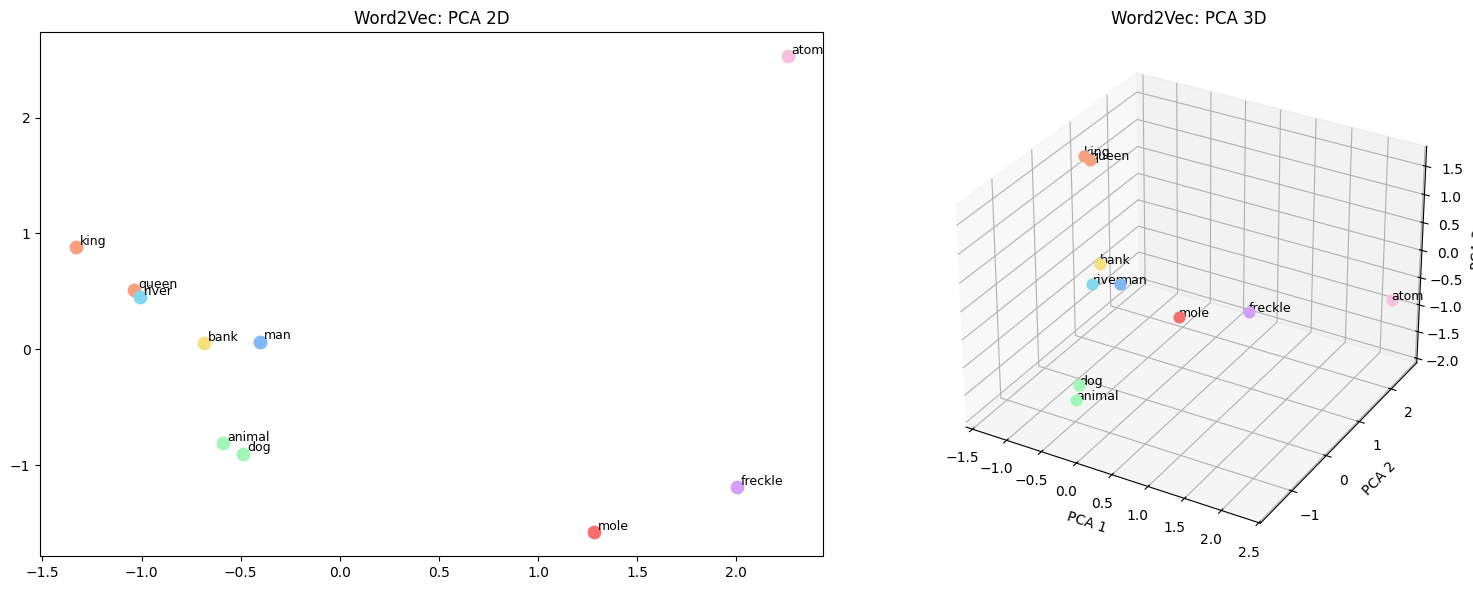

In [9]:
w2v_vecs = np.array([w2v[w] for w in words])
w2v_2d = PCA(n_components=2).fit_transform(w2v_vecs)
w2v_3d = PCA(n_components=3).fit_transform(w2v_vecs)

fig = plt.figure(figsize=(16, 6))

# 2D
ax2 = fig.add_subplot(121)
for i, w in enumerate(words):
    c = group_colors[word_groups[w]]
    x, y = w2v_2d[i]
    ax2.scatter(x, y, color=c, s=80)
    ax2.text(x + 0.02, y + 0.02, w, fontsize=9)
ax2.set_title('Word2Vec: PCA 2D')

# 3D
ax3 = fig.add_subplot(122, projection='3d')
for i, w in enumerate(words):
    c = group_colors[word_groups[w]]
    ax3.scatter(w2v_3d[i, 0], w2v_3d[i, 1], w2v_3d[i, 2], color=c, s=60)
    ax3.text(w2v_3d[i, 0], w2v_3d[i, 1], w2v_3d[i, 2], w, size=9)
ax3.set_xlabel('PCA 1')
ax3.set_ylabel('PCA 2')
ax3.set_zlabel('PCA 3')
ax3.set_title('Word2Vec: PCA 3D')

plt.tight_layout()
plt.show()

---
## Transformer Encoder

A Transformer encoder processes an entire input sequence simultaneously using **self-attention**, which allows each token to attend to every other token in the sequence. This produces a **contextual embedding**, which is a vector that depends not just on the word itself, but on its surrounding context [https://en.wikipedia.org/wiki/Transformer_(deep_learning)].

This is in direct contrast to Word2Vec, which assigns a single static vector to each word regardless of context.

We use **BERT** (*Bidirectional Encoder Representations from Transformers*, [https://arxiv.org/abs/1810.04805]), specifically `bert-base-uncased` from the HuggingFace `transformers` library [https://huggingface.co/docs/transformers/model_doc/bert]. We chose BERT because:
- it is a **Transformer encoder** — directly matching the requirement of this task
- it processes sequences **bidirectionally**, attending to both left and right context simultaneously
- the pretrained model is readily available and requires no additional training
- embeddings are easily extracted from the last hidden layer

In [10]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')
bert.eval()

def get_bert_embedding(sentence, target_word):
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    with torch.no_grad():
        outputs = bert(**inputs)

    hidden = outputs.last_hidden_state[0]  # (seq_len, 768)

    target_tokens = tokenizer.tokenize(target_word)
    for i in range(len(tokens) - len(target_tokens) + 1):
        if tokens[i:i+len(target_tokens)] == target_tokens:
            return hidden[i:i+len(target_tokens)].mean(0).numpy()

    raise ValueError(f"'{target_word}' not found in sentence")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Cosine Similarity

Same word pairs as above, but now each word is embedded in its sentence context before computing similarity.

In [11]:
bert_pairs = [
    ('king',             'queen',      'king',  'queen'),
    ('king',             'man',        'king',  'man'),
    ('dog',              'animal',     'dog',   'animal'),
    ('bank',             'river',      'bank',  'river'),
    ('mole (skin)',      'freckle',    'mole',  'freckle'),   # skin mole vs freckle
    ('mole (chemistry)', 'atom',  'mole',  'atom'), # chemistry mole vs atom
    ('mole (animal)',    'animal',     'mole',  'animal'),    # animal mole vs animal
]

print(f'{"Label A":<22} {"Label B":<22} {"BERT sim":>10}')
print('-' * 56)
for la, lb, wa, wb in bert_pairs:
    sa, _ = bert_sentences[la]
    sb, _ = bert_sentences[lb]
    emb_a = get_bert_embedding(sa, wa)
    emb_b = get_bert_embedding(sb, wb)
    sim = cos_sim([emb_a], [emb_b])[0][0]
    print(f'{la:<22} {lb:<22} {sim:>10.4f}')

Label A                Label B                  BERT sim
--------------------------------------------------------
king                   queen                      0.6016
king                   man                        0.5415
dog                    animal                     0.6603
bank                   river                      0.4465
mole (skin)            freckle                    0.5409
mole (chemistry)       atom                       0.4844
mole (animal)          animal                     0.4917


In [12]:
bert_vectors = np.array([
    get_bert_embedding(sent, target)
    for label, (sent, target) in bert_sentences.items()
])

### Visualization: PCA

Same PCA visualization as Word2Vec. 2D and 3D side by side. The three `mole` senses should appear in different regions of the space.

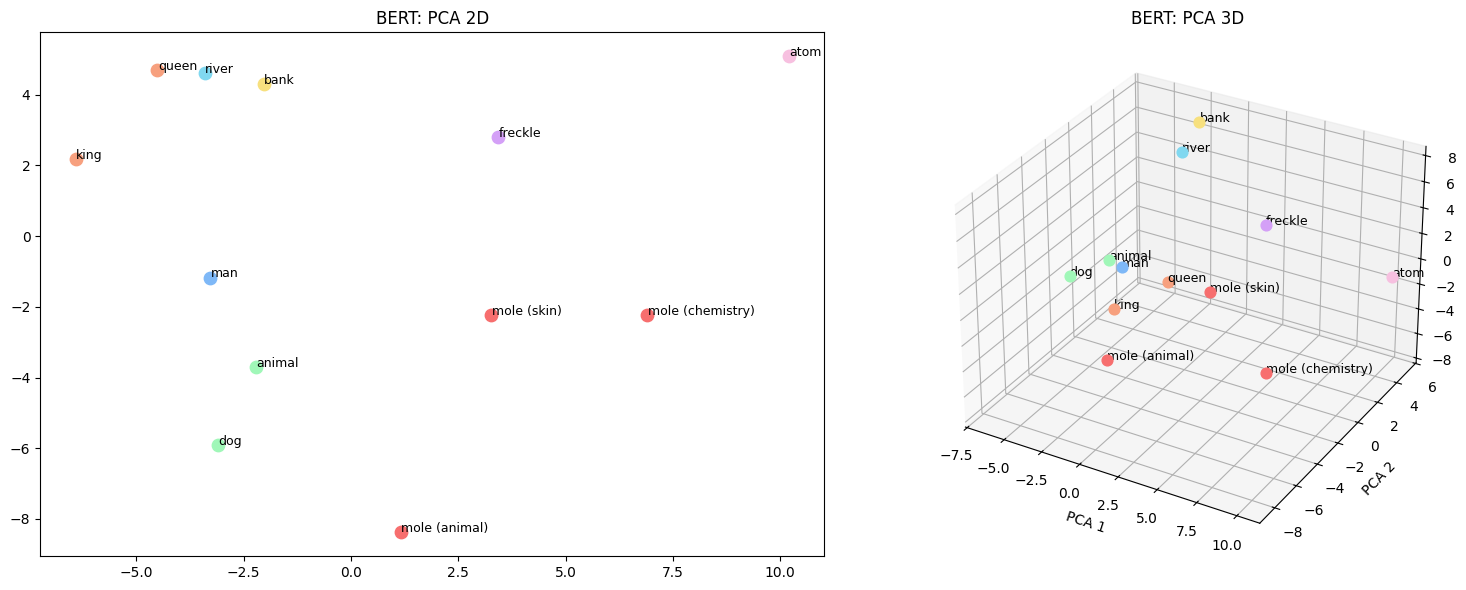

In [13]:
bert_2d = PCA(n_components=2).fit_transform(bert_vectors)
bert_3d_vecs = PCA(n_components=3).fit_transform(bert_vectors)

fig = plt.figure(figsize=(16, 6))

# 2D
ax2 = fig.add_subplot(121)
for i, word in enumerate(bert_words):
    c = group_colors[word_groups[word]]
    x, y = bert_2d[i]
    ax2.scatter(x, y, color=c, s=80)
    ax2.text(x + 0.01, y + 0.01, word, fontsize=9)
ax2.set_title('BERT: PCA 2D')

# 3D
ax3 = fig.add_subplot(122, projection='3d')
for i, word in enumerate(bert_words):
    c = group_colors[word_groups[word]]
    ax3.scatter(bert_3d_vecs[i, 0], bert_3d_vecs[i, 1], bert_3d_vecs[i, 2], color=c, s=60)
    ax3.text(bert_3d_vecs[i, 0], bert_3d_vecs[i, 1], bert_3d_vecs[i, 2], word, size=9)
ax3.set_xlabel('PCA 1')
ax3.set_ylabel('PCA 2')
ax3.set_zlabel('PCA 3')
ax3.set_title('BERT: PCA 3D')

plt.tight_layout()
plt.show()

## Transformer Encoder vs. Word2Vec

Direct comparison of both models on the same word pairs and the same words.

### Cosine Similarity Comparison

In [14]:
print(f'{"W2V pair":<20} {"BERT pair":<30} {"W2V sim":>8} {"BERT sim":>9}')
print('-' * 70)

compare = [
    ('mole', 'freckle',  'mole (skin)',      'freckle'),
    ('mole', 'atom',     'mole (chemistry)', 'atom'),
    ('mole', 'animal',   'mole (animal)',    'animal'),
    ('king', 'queen',    'king',             'queen'),
    ('king', 'man',      'king',             'man'),
    ('dog',  'animal',   'dog',              'animal'),
    ('bank', 'river',    'bank',             'river'),
]

for w2v_a, w2v_b, bert_la, bert_lb in compare:
    w2v_sim = w2v.similarity(w2v_a, w2v_b)
    sa, wa = bert_sentences[bert_la]
    sb, wb = bert_sentences[bert_lb]
    emb_a = get_bert_embedding(sa, wa)
    emb_b = get_bert_embedding(sb, wb)
    bert_sim = cos_sim([emb_a], [emb_b])[0][0]
    print(f'{w2v_a+"/"+w2v_b:<20} {bert_la+"/"+bert_lb:<30} {w2v_sim:>8.4f} {bert_sim:>9.4f}')

W2V pair             BERT pair                       W2V sim  BERT sim
----------------------------------------------------------------------
mole/freckle         mole (skin)/freckle              0.4830    0.5409
mole/atom            mole (chemistry)/atom            0.1221    0.4844
mole/animal          mole (animal)/animal             0.1172    0.4917
king/queen           king/queen                       0.6511    0.6016
king/man             king/man                         0.2294    0.5415
dog/animal           dog/animal                       0.6438    0.6603
bank/river           bank/river                       0.2152    0.4465


### Interactive 3D Comparison

Both models projected to 3D with PCA [https://plotly.com/python/3d-scatter-plots/]. Colors represent semantic groups. Rotate each plot to explore the geometry. In the W2V plot `mole` appears once; in the BERT plot it appears three times, one per sense.

In [15]:
w2v_3d = PCA(n_components=3).fit_transform(w2v_vecs)
bert_3d = PCA(n_components=3).fit_transform(bert_vectors)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=['Word2Vec (one point per word)', 'BERT (mole appears 3x)']
)

# W2V
seen = set()
for i, word in enumerate(words):
    group = word_groups[word]
    color = group_colors[group]
    show = group not in seen
    seen.add(group)
    fig.add_trace(go.Scatter3d(
        x=[w2v_3d[i, 0]], y=[w2v_3d[i, 1]], z=[w2v_3d[i, 2]],
        mode='markers+text', text=[word], textposition='top center',
        marker=dict(size=8, color=color, opacity=0.9),
        name=group, legendgroup=group, showlegend=show,
        hovertemplate=f'<b>{word}</b><br>{group}<extra></extra>',
    ), row=1, col=1)

# BERT
seen = set()
for i, word in enumerate(bert_words):
    group = word_groups[word]
    color = group_colors[group]
    show = group not in seen
    seen.add(group)
    fig.add_trace(go.Scatter3d(
        x=[bert_3d[i, 0]], y=[bert_3d[i, 1]], z=[bert_3d[i, 2]],
        mode='markers+text', text=[word], textposition='top center',
        marker=dict(size=8, color=color, opacity=0.9),
        name=group, legendgroup=group, showlegend=False,
        hovertemplate=f'<b>{word}</b><br>{group}<extra></extra>',
    ), row=1, col=2)

fig.update_layout(title='Word2Vec vs BERT embeddings: PCA 3D', height=650)
fig.show()

## Negative Example

*(TODO)*

## Try It Yourself

In [17]:
style = {'description_width': '120px'}
wide  = widgets.Layout(width='620px')
mid   = widgets.Layout(width='380px')

s1_input = widgets.Text(value='The bank approved my loan application.',
                        description='Sentence 1:', style=style, layout=wide)
w1_input = widgets.Text(value='bank', description='Word in S1:',
                        style=style, layout=mid)
s2_input = widgets.Text(value='We sat on the bank of the river and watched the ducks.',
                        description='Sentence 2:', style=style, layout=wide)
w2_input = widgets.Text(value='bank', description='Word in S2:',
                        style=style, layout=mid)

button = widgets.Button(description='Compare', button_style='primary',
                        layout=widgets.Layout(width='160px', height='36px'))
out = widgets.Output()

def on_click(b):
    out.clear_output()
    with out:
        s1, s2 = s1_input.value, s2_input.value
        ww1 = w1_input.value.strip().lower()
        ww2 = w2_input.value.strip().lower()

        try:
            u_bert_1 = get_bert_embedding(s1, ww1)
            u_bert_2 = get_bert_embedding(s2, ww2)
        except ValueError as e:
            print(f'BERT error: {e}'); return

        missing = [w for w in [ww1, ww2] if w not in w2v]
        if missing:
            print(f'Not in Word2Vec vocabulary: {missing}'); return

        u_w2v_1 = w2v[ww1]
        u_w2v_2 = w2v[ww2]

        u_labels   = [f'{ww1} (S1)', f'{ww2} (S2)']
        u_colors   = ["#fdfdfd", '#ffff66']

        all_w2v    = np.vstack([w2v_vecs,    u_w2v_1,  u_w2v_2])
        all_bert   = np.vstack([bert_vectors, u_bert_1, u_bert_2])
        w2v_labels = words      + u_labels
        b_labels   = bert_words + u_labels
        w2v_colors = [group_colors[word_groups[w]] for w in words]      + u_colors
        b_colors   = [group_colors[word_groups[w]] for w in bert_words] + u_colors

        w2v_proj  = PCA(n_components=3).fit_transform(all_w2v)
        bert_proj = PCA(n_components=3).fit_transform(all_bert)

        fig = make_subplots(
            rows=1, cols=2,
            specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
            subplot_titles=['Word2Vec (static)', 'BERT (contextual)']
        )

        for col, (proj, labels, colors) in enumerate(
            [(w2v_proj, w2v_labels, w2v_colors),
             (bert_proj, b_labels,  b_colors)], start=1):
            for i, (label, color) in enumerate(zip(labels, colors)):
                is_user = label in u_labels
                fig.add_trace(go.Scatter3d(
                    x=[proj[i,0]], y=[proj[i,1]], z=[proj[i,2]],
                    mode='markers+text', text=[label], textposition='top center',
                    marker=dict(
                        size= 7,
                        color=color,
                        opacity=1.0 if is_user else 0.7,
                        line=dict(color='black', width=2) if is_user else dict()
                    ),
                    showlegend=False,
                    hovertemplate=f'<b>{label}</b><extra></extra>',
                ), row=1, col=col)

        sim_w2v  = cos_sim([u_w2v_1],  [u_w2v_2])[0][0]
        sim_bert = cos_sim([u_bert_1], [u_bert_2])[0][0]
        print(f'Cosine similarity — W2V: {sim_w2v:.4f} | BERT: {sim_bert:.4f}')

        fig.update_layout(title='Your words vs existing embeddings', height=650)
        fig.show()

button.on_click(on_click)
display(
    widgets.HTML('<b>Sentence 1</b>'),
    s1_input, w1_input,
    widgets.HTML('<br><b>Sentence 2</b>'),
    s2_input, w2_input,
    widgets.HTML('<br>'),
    button, out
)

HTML(value='<b>Sentence 1</b>')

Text(value='The bank approved my loan application.', description='Sentence 1:', layout=Layout(width='620px'), …

Text(value='bank', description='Word in S1:', layout=Layout(width='380px'), style=TextStyle(description_width=…

HTML(value='<br><b>Sentence 2</b>')

Text(value='We sat on the bank of the river and watched the ducks.', description='Sentence 2:', layout=Layout(…

Text(value='bank', description='Word in S2:', layout=Layout(width='380px'), style=TextStyle(description_width=…

HTML(value='<br>')

Button(button_style='primary', description='Compare', layout=Layout(height='36px', width='160px'), style=Butto…

Output()

## Contributions

**Natalia Sperczyńska (278444):**

**Weronika Łaszkiewicz (278434):**

## References

Faculty of Fundamental Problems of Technology, Wrocław University of Science and Technology. *Artificial Intelligence 1 — Modelling Sequential Data*, Lecture 1.9A, available via ePortal.

**Papers:**
- Vaswani, A. et al. (2017). *Attention Is All You Need.* [https://arxiv.org/abs/1706.03762]
- Devlin, J. et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* [https://arxiv.org/abs/1810.04805]

**Documentation:**
- gensim — [https://radimrehurek.com/gensim/models/word2vec.html]
- gensim-data — [https://github.com/piskvorky/gensim-data]
- gensim KeyedVectors — [https://radimrehurek.com/gensim/models/keyedvectors.html]
- HuggingFace transformers — [https://huggingface.co/docs/transformers/index]
- BERT model card — [https://huggingface.co/docs/transformers/model_doc/bert]
- scikit-learn PCA — [https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html]
- plotly 3D scatter — [https://plotly.com/python/3d-scatter-plots/]

**Additional reading:**
- Wikipedia, Word2vec — [https://en.wikipedia.org/wiki/Word2vec]
- Wikipedia, Transformer — [https://en.wikipedia.org/wiki/Transformer_(deep_learning)]
- Alammar, J. *The Illustrated Word2Vec* — [https://jalammar.github.io/illustrated-word2vec/]
- Alammar, J. *The Illustrated Transformer* — [https://jalammar.github.io/illustrated-transformer/]
- Transformer Explainer (interactive) — [https://poloclub.github.io/transformer-explainer/]
- [https://machinelearningmastery.com/text-embedding-generation-with-transformers/]
- [https://www.nn-visual.com/transformer]

**Tools:**
- Gemini — example sentences and plot assistance

## TODO

- [ ] Negative example
- [ ] Fill in contributions
- [ ] Write `requirements.txt`